# Exercise E3

This notebook produces the following maps

* The Antarctic continent and the Southern Ocean starting from 60°S
* The South Atlantic, from 20°S to 50°S. The map should show the following locations: Walvis Bay, Cape Town, Rio de Janeiro, Montevideo

In [2]:
import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
# these modules will be used later
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

In [4]:
import warnings
warnings.filterwarnings("ignore",category=RuntimeWarning)

## Exercise 1: South Pole

/opt/anaconda3/envs/SAMOS/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


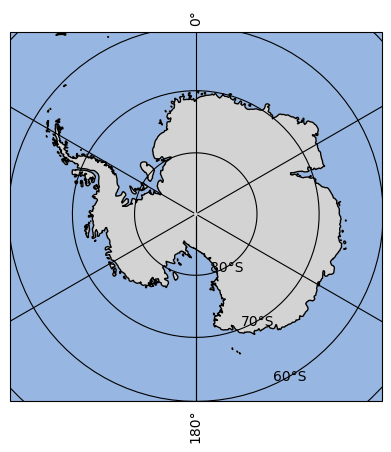

In [51]:
plt.figure()
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAND, color='lightgray')
ax.gridlines(draw_labels=True, color='black')

## Exercise 2: South Atlantic 

[Location(Walvis Bay, Erongo Region, 13013, Namibia, (-22.9557607, 14.5071125, 0.0)), Location(Cape Town, City of Cape Town, Western Cape, 8001, South Africa, (-33.9288301, 18.4172197, 0.0)), Location(Rio de Janeiro, Southeast Region, Brazil, (-22.9110137, -43.2093727, 0.0)), Location(Montevideo, Uruguay, (-34.9058916, -56.1913095, 0.0))]


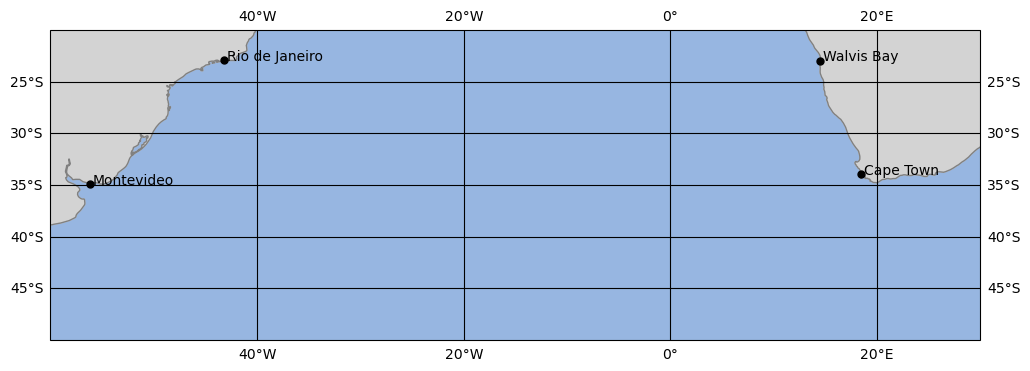

In [55]:
geolocator = Nominatim(user_agent='educational')

# a map of the Mediterranean, with a few places
extent = [-60, 30, -50, -20]
central_lon = np.mean(extent[:2])
central_lat = np.mean(extent[2:])

place = ['Walvis Bay', 'Cape Town', 'Rio de Janeiro', 'Montevideo']
address = []
for p in place:
    loc = geolocator.geocode(p,language="en")
    address.append(loc)
print(address)

plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.coastlines(color='gray')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAND, color='lightgray')
ax.gridlines(draw_labels=True, color='black')
for p in range(len(place)):
    ax.plot(address[p].longitude,address[p].latitude,'ko',markersize=5,transform=ccrs.Geodetic())
    ax.text(address[p].longitude+0.3,address[p].latitude,place[p],transform=ccrs.Geodetic())